# 01 — Análise Exploratória de Dados (EDA)

**Pergunta orientadora:** quais fatores operacionais (pedido, logística, atendimento) fazem o NPS variar entre os clientes e onde está o ponto de ruptura da experiência?

A análise segue o processo da disciplina de EDA: qualidade dos dados → classificação das variáveis → análise univariada → bivariada → multivariada → registro de hipóteses. O código reutiliza as funções de `src/data_prep.py` e `src/eda.py`.

In [1]:
import pandas as pd
from IPython.display import Image, display

from tech_challenge_fase1 import data_prep as dp
from tech_challenge_fase1 import eda
from tech_challenge_fase1.config import RAW_DATA_FILE, PROCESSED_DATA_FILE, FIGURES_DIR

pd.set_option('display.width', 120)

## 1. Qualidade dos dados
Checagem das dimensões de qualidade (completude, consistência, validade, unicidade). A base não tem valores ausentes nem duplicatas, e os IDs são únicos.

In [2]:
raw_df = dp.load_raw_data(RAW_DATA_FILE)
dp.validate_data(raw_df)

{'shape': (2500, 19),
 'missing_total': 0,
 'missing_by_column': {},
 'duplicate_rows': 0,
 'id_uniqueness': {'customer_id': 2500, 'order_id': 2500},
 'out_of_range': {}}

In [3]:
# Constrói o dataset limpo e pronto para análise (adiciona nps_category e is_detractor)
df = dp.build_processed_dataset(RAW_DATA_FILE, PROCESSED_DATA_FILE)
print('Shape:', df.shape)
df.head()

Shape: (2500, 21)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_category,is_detractor
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,Detrator,1
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,Detrator,1
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,Detrator,1
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,Detrator,1
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,Detrator,1


## 2. Classificação das variáveis
- **Numéricas contínuas:** `order_value`, `discount_value`, `freight_value`, `nps_score`, `csat_internal_score`.
- **Numéricas discretas (contagens/dias):** `delivery_time_days`, `delivery_delay_days`, `delivery_attempts`, `customer_service_contacts`, `resolution_time_days`, `complaints_count`, `items_quantity`, `payment_installments`, `customer_age`, `customer_tenure_months`.
- **Categórica nominal:** `customer_region`.
- **Booleana:** `repeat_purchase_30d`.
- **Alvo:** `nps_score` (0–10).

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


## 3. Distribuição do NPS
O NPS varia de 0 a 10. Pela régua padrão: **Detrator (<7)**, **Neutro (7–8)**, **Promotor (9–10)**. O resultado é alarmante: a maioria é detratora e o NPS consolidado fica em **−80**.

NPS (% promotores - % detratores): -80.0


,count,pct
nps_category,,
Detrator,2109,84.4
Neutro,281,11.2
Promotor,110,4.4


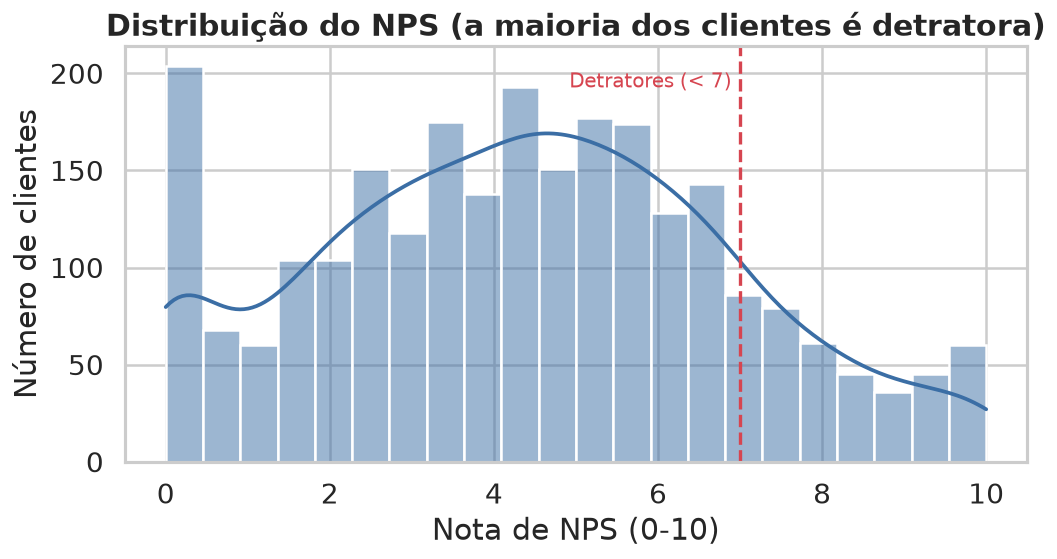

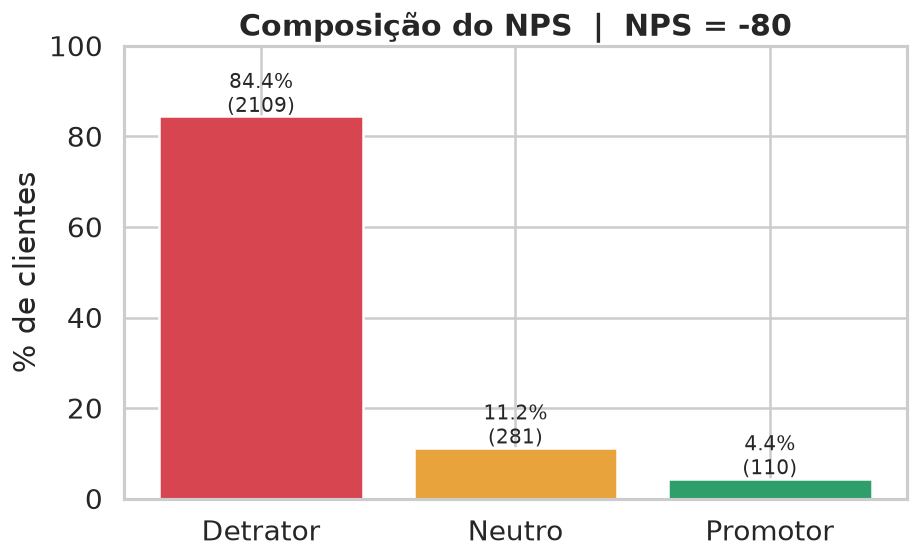

In [5]:
print('NPS (% promotores - % detratores):', eda.compute_nps_metric(df))
display(eda.segment_distribution(df))
paths = eda.generate_all_figures(df)
display(Image(paths['nps_distribution']))
display(Image(paths['nps_segments']))

## 4. O que move o NPS? (análise multivariada)
Correlação de **Spearman** (monotônica, robusta a outliers) de cada variável operacional com o NPS. Quatro variáveis se destacam — todas de **logística e atendimento**.

,spearman_vs_nps
delivery_delay_days,-0.586
complaints_count,-0.490
customer_service_contacts,-0.336
resolution_time_days,-0.190
freight_value,-0.040
customer_tenure_months,-0.012
customer_age,-0.007
delivery_time_days,0.000
items_quantity,0.006
discount_value,0.012


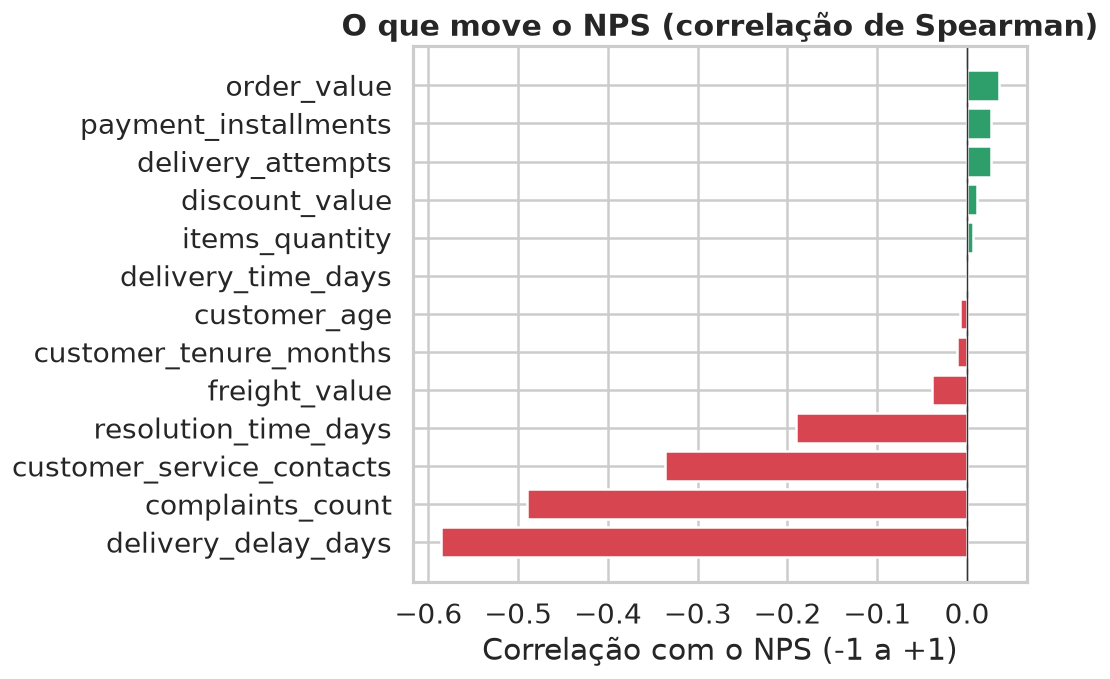

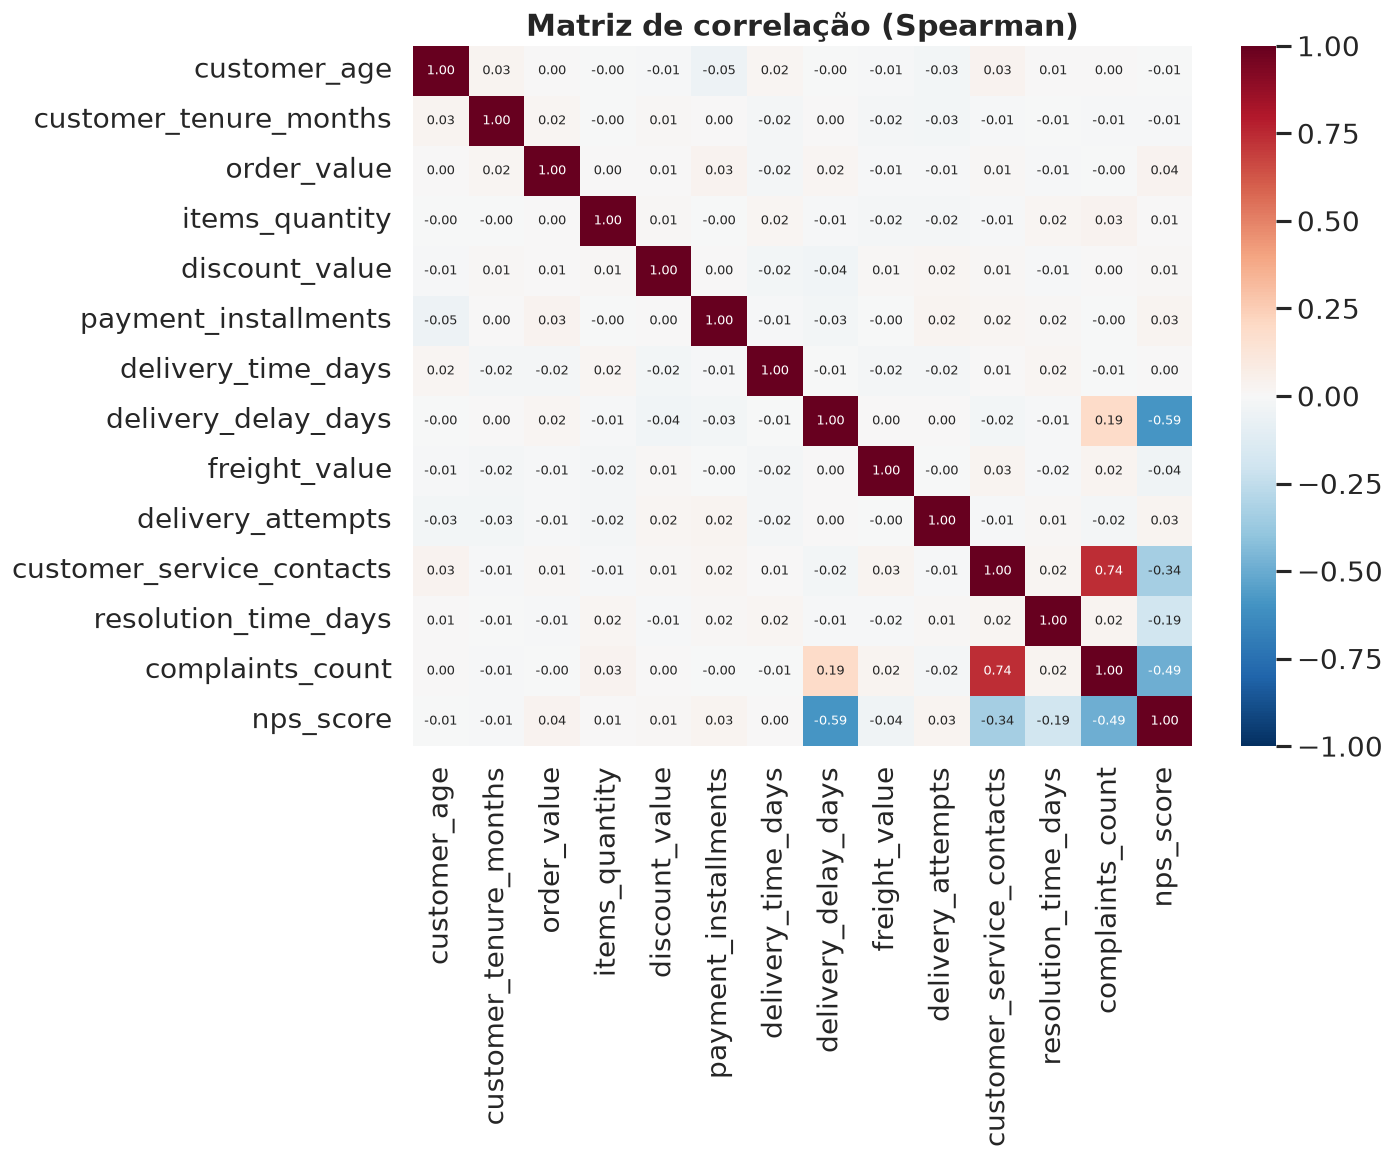

In [6]:
display(eda.spearman_with_target(df).round(3).to_frame('spearman_vs_nps'))
display(Image(paths['driver_ranking']))
display(Image(paths['correlation_heatmap']))

## 5. O ponto de ruptura: atraso na entrega
`delivery_delay_days` é o fator nº 1 (Spearman ≈ −0,59). Repare: `delivery_time_days` (tempo total) tem correlação ~0. **O que machuca não é demorar, é atrasar em relação ao prometido.** Cada dia de atraso derruba o NPS em ~1 ponto; com 0 dia o cliente está perto de promotor (~6,9), e a partir de ~2 dias ele já é detrator.

,mean,count
delivery_delay_days,,
0,6.86,277
1,5.55,615
2,4.58,646
3,3.44,525
4,2.44,270
5,1.48,116
6,1.10,34
7,0.29,14
8,0.00,3


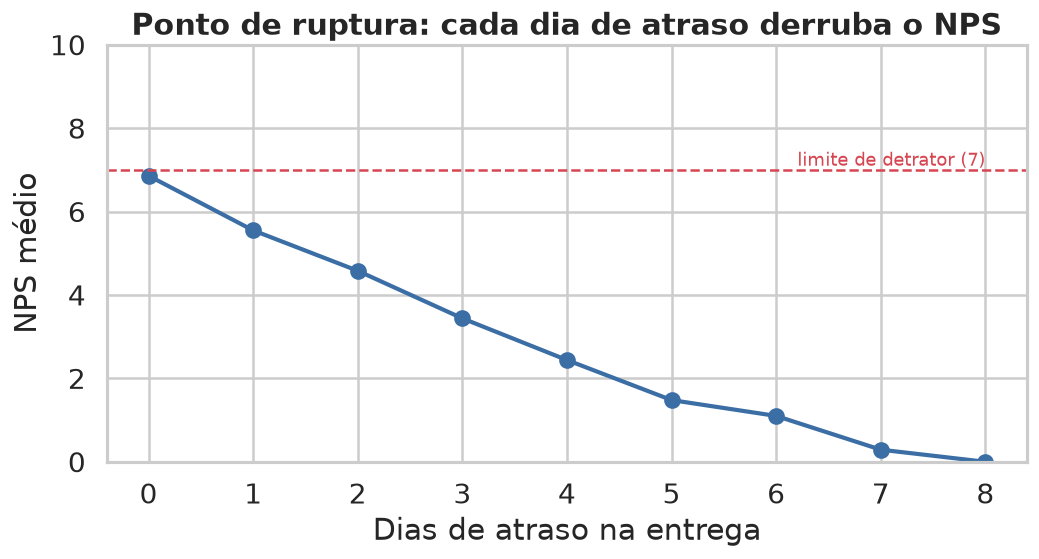

In [8]:
display(eda.mean_nps_by(df, 'delivery_delay_days'))
display(Image(paths['nps_by_delay']))

## 6. Atrito de atendimento (reclamações e contatos)
Cada reclamação e cada novo contato com o SAC reduzem o NPS de forma consistente — sinal de que o cliente que precisa acionar o suporte já está vivendo uma experiência ruim.

,mean,count
complaints_count,,
0,8.52,23
1,7.77,122
2,6.05,277
3,4.91,507
4,4.22,600
5,3.65,444
6,3.06,266
7,2.81,169
8,2.07,63


,mean,count
customer_service_contacts,,
0,5.54,554
1,4.66,816
2,4.12,640
3,3.20,314
4,2.65,132
5,2.24,34
6,0.74,7
7,1.20,3


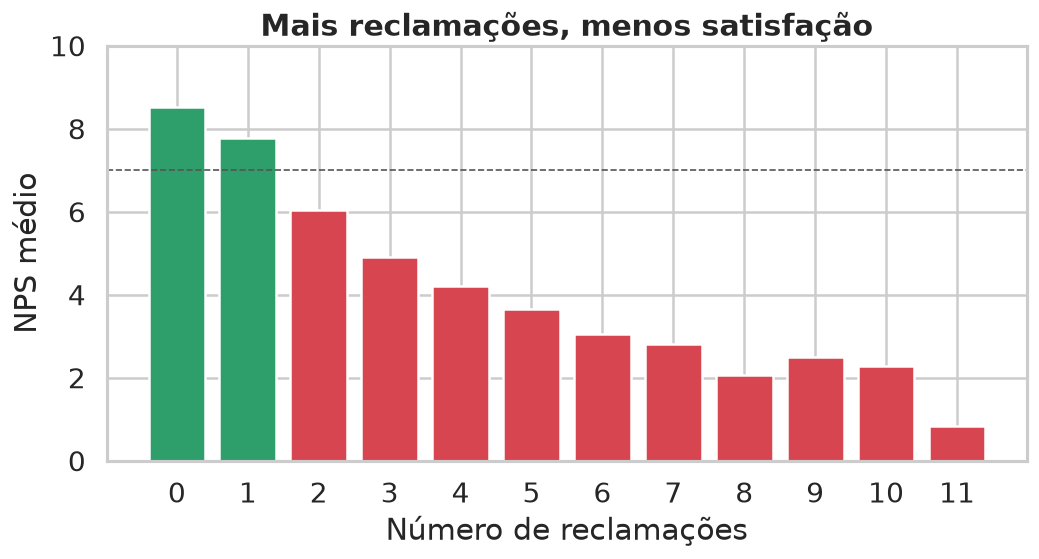

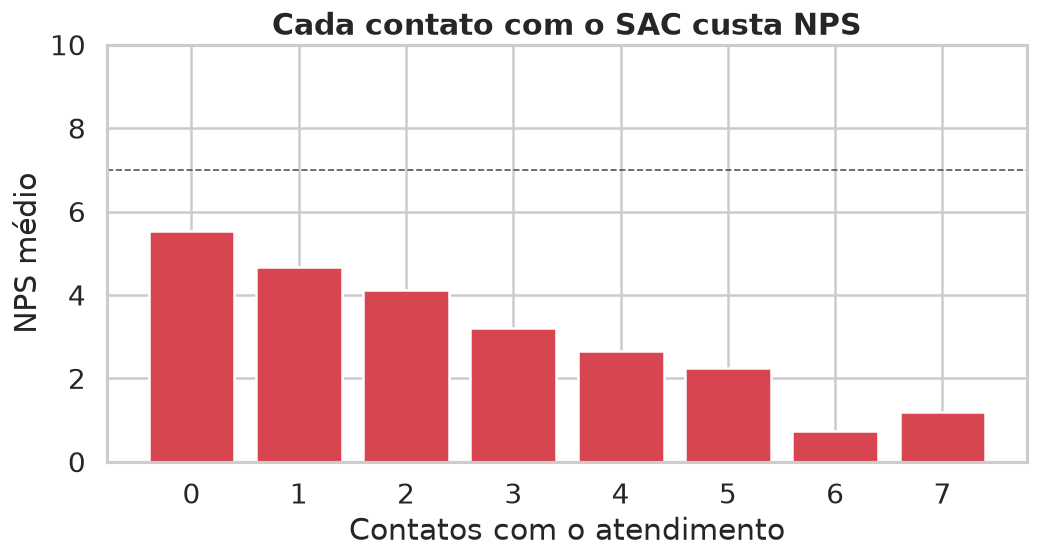

In [10]:
display(eda.mean_nps_by(df, 'complaints_count'))
display(eda.mean_nps_by(df, 'customer_service_contacts'))
display(Image(paths['nps_by_complaints']))
display(Image(paths['nps_by_contacts']))

## 7. Perfil do cliente e geografia (quase não importam)
Idade, tempo de casa, valor do pedido, desconto, frete e parcelas têm correlação ~0 com o NPS. A diferença entre regiões é pequena (médias de 4,2 a 4,5). **Satisfação aqui é definida pela experiência operacional, não pelo perfil de quem compra.**

,mean,count
customer_region,,
Centro-Oeste,4.21,468
Nordeste,4.42,485
Norte,4.38,506
Sudeste,4.37,520
Sul,4.49,521


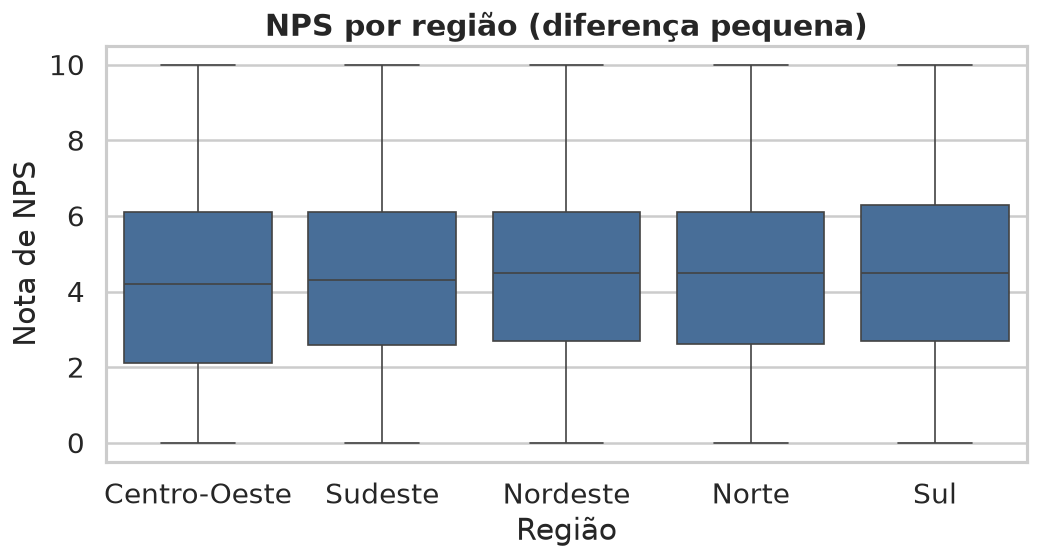

In [12]:
display(df.groupby('customer_region')['nps_score'].agg(['mean', 'count']).round(2))
display(Image(paths['nps_by_region']))

## 8. Síntese (observação → evidência → hipótese)
| Observação | Evidência | Hipótese / próximo passo |
|---|---|---|
| Atraso é o maior vilão | Spearman −0,59; NPS cai ~1 ponto/dia de atraso | Priorizar SLA de entrega e comunicação proativa de atraso |
| Atendimento repetido derruba NPS | complaints −0,49; contatos −0,34 | Resolver no 1º contato; atacar causa-raiz das reclamações |
| Tempo total de entrega não importa | corr ~0 | Gerenciar **expectativa vs. realizado**, não só velocidade |
| Perfil/geografia ~irrelevantes | corr ~0; regiões 4,2–4,5 | Ação deve ser operacional e transversal, não segmentada por perfil |

**Cliente com NPS alto:** entrega no prazo, sem reclamações, sem acionar o SAC. **Cliente com NPS baixo:** sofreu atraso e/ou abriu reclamações e contatos.

Correlação não é causalidade — mas o padrão é forte, consistente e operacionalmente acionável.